# FinSight Agent — 3-Way Evaluation Analysis

This notebook compiles the evaluation results for the three RAG modes:

- **Naive RAG** — baseline (retrieve + generate)
- **Agentic RAG** — single-agent with 4-state router + self-reflection
- **Multi-Agent RAG** — 4 specialized agents (Planner, Decomposer, Synthesizer, Validator)

It reads the three results CSVs produced by `eval_script.py`, computes per-mode averages on the rubric metrics, displays a comparison table, and saves a bar chart to `comparison_chart.png`.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

EVAL_DIR = Path('.')  # notebook lives in evaluation/ so CSVs are in the same folder
MODES = ['naive', 'agentic', 'multi_agent']
MODE_LABELS = {'naive': 'Naive RAG', 'agentic': 'Agentic RAG', 'multi_agent': 'Multi-Agent RAG'}
MODE_COLORS = {'naive': '#9aa0a6', 'agentic': '#1a73e8', 'multi_agent': '#34a853'}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10})

## 2. Load evaluation results

Read the three per-mode CSVs and concatenate them into one long-format DataFrame.

In [2]:
dfs = {}
for mode in MODES:
    path = EVAL_DIR / f'results_{mode}.csv'
    dfs[mode] = pd.read_csv(path)
    print(f'{mode:>12}: {len(dfs[mode])} rows from {path.name}')

df = pd.concat(dfs.values(), ignore_index=True)
print(f'\nCombined: {len(df)} rows across {df["mode"].nunique()} modes')
df.head()

       naive: 15 rows from results_naive.csv
     agentic: 15 rows from results_agentic.csv
 multi_agent: 15 rows from results_multi_agent.csv

Combined: 45 rows across 3 modes


,question_id,category,question,mode,answer,decision,execution_time_s,relevance,faithfulness,has_citations,correct_abstention,confidence,num_chunks,answer_length,error
0,F1,Factual,What was Apple's total revenue in fiscal year ...,naive,Apple's total revenue in fiscal year 2025 was ...,ANSWER,3.91,0.613,1.0,1,1,0.94,5,184,NaN
1,F2,Factual,Who is the CEO of Apple Inc.?,naive,"The CEO of Apple Inc. is Timothy D. Cook, as s...",ANSWER,3.72,0.807,0.9,1,1,0.95,5,242,NaN
2,F3,Factual,What was Amazon's net sales in Q1 2026?,naive,Amazon's net sales in Q1 2026 were $181.5 bill...,ANSWER,2.36,0.530,1.0,1,1,0.93,5,159,NaN
3,F4,Factual,What does NVIDIA primarily manufacture?,naive,NVIDIA primarily manufactures products related...,ANSWER,3.39,1.000,0.9,1,1,0.97,5,373,NaN
4,F5,Factual,What is Apple's services segment revenue in 2025?,naive,Apple's services segment revenue in 2025 was $...,ANSWER,2.46,0.820,1.0,1,1,0.95,5,246,NaN


In [3]:
# Quick sanity check: are all questions present in every mode?
print('Questions per mode:')
print(df.groupby('mode')['question_id'].nunique())

print('\nCategory mix:')
print(df.groupby(['mode', 'category']).size().unstack(fill_value=0))

Questions per mode:
mode
agentic        15
multi_agent    15
naive          15
Name: question_id, dtype: int64

Category mix:
category     Comparison  Factual  Reasoning  Should-Refuse
mode                                                      
agentic               4        5          3              3
multi_agent           4        5          3              3
naive                 4        5          3              3


## 3. Compute per-mode metrics

We aggregate six metrics per mode:

| Metric | Range | Meaning |
|--------|-------|---------|
| **Relevance** | 0–1 | Did the answer address the question (heuristic proxy) |
| **Faithfulness** | 0–1 | Was the answer supported by retrieved chunks |
| **Citation Accuracy** | 0–100% | % of responses with citations |
| **Correct Abstention** | 0–100% | % of responses where the system did the right thing on the should-refuse set |
| **Confidence** | 0–1 | Self-reported confidence |
| **Latency** | seconds | End-to-end response time |

In [4]:
def per_mode_summary(d: pd.DataFrame) -> dict:
    return {
        'Avg Relevance':       round(d['relevance'].mean(), 3),
        'Avg Faithfulness':    round(d['faithfulness'].mean(), 3),
        'Citation Accuracy %': round(d['has_citations'].mean() * 100, 1),
        'Correct Abstention %': round(d['correct_abstention'].mean() * 100, 1),
        'Avg Confidence':      round(d['confidence'].mean(), 3),
        'Avg Latency (s)':     round(d['execution_time_s'].mean(), 2),
    }

summary = {MODE_LABELS[m]: per_mode_summary(dfs[m]) for m in MODES}
comparison = pd.DataFrame(summary)
comparison

,Naive RAG,Agentic RAG,Multi-Agent RAG
Avg Relevance,0.835,0.920,0.917
Avg Faithfulness,0.947,0.753,0.893
Citation Accuracy %,100.000,100.000,100.000
Correct Abstention %,80.000,53.300,73.300
Avg Confidence,0.959,0.325,0.591
Avg Latency (s),2.960,6.880,16.380


### 3a. Improvement vs Naive baseline

For each quality metric, how much does Agentic / Multi-Agent improve over the Naive baseline?

In [5]:
improvement = pd.DataFrame({
    'Naive RAG': comparison['Naive RAG'],
    'Agentic Δ vs Naive': (comparison['Agentic RAG'] - comparison['Naive RAG']).round(3),
    'Multi-Agent Δ vs Naive': (comparison['Multi-Agent RAG'] - comparison['Naive RAG']).round(3),
})
improvement

,Naive RAG,Agentic Δ vs Naive,Multi-Agent Δ vs Naive
Avg Relevance,0.835,0.085,0.082
Avg Faithfulness,0.947,-0.194,-0.054
Citation Accuracy %,100.000,0.000,0.000
Correct Abstention %,80.000,-26.700,-6.700
Avg Confidence,0.959,-0.634,-0.368
Avg Latency (s),2.960,3.920,13.420


## 4. Visualization — comparison bar chart

Two side-by-side subplots:

- **Left:** quality metrics (Relevance, Faithfulness, Citation %, Correct Abstention %, Confidence) — different scales but normalized to 0–1 / 0–100 for display
- **Right:** latency in seconds (separate scale)

The chart is saved to `evaluation/comparison_chart.png` and used in `docs/evaluation_results.md`.

Saved chart to: C:\Users\ANUSHREE ASHOK\Desktop\MAIB\Term 5\Advanced Topics in Generative AI\Final Group Assignment\evaluation\comparison_chart.png


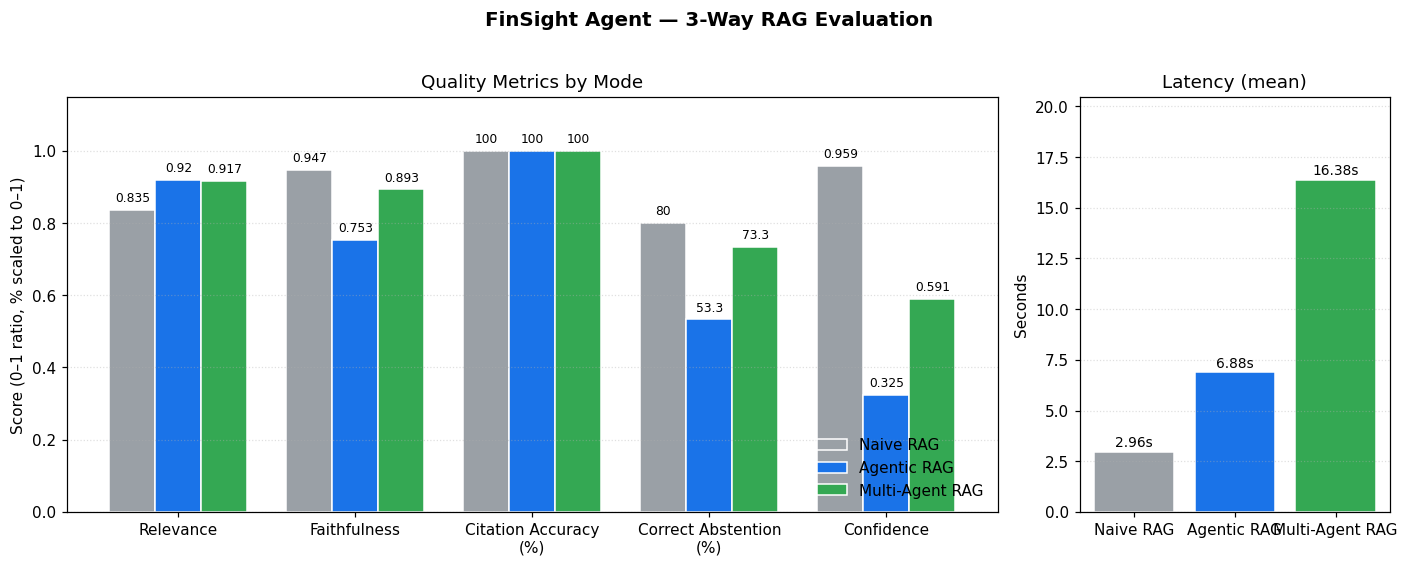

In [6]:
# Build a tidy long-format frame for plotting
quality_metrics = ['Avg Relevance', 'Avg Faithfulness', 'Citation Accuracy %', 'Correct Abstention %', 'Avg Confidence']
latency_metric = 'Avg Latency (s)'

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [3, 1]})

# --- Left subplot: quality metrics ---
x = np.arange(len(quality_metrics))
width = 0.26
for i, mode in enumerate(MODES):
    label = MODE_LABELS[mode]
    values = [comparison.loc[m, label] for m in quality_metrics]
    # Normalize: percent metrics live on 0-100 already, ratio metrics on 0-1.
    # Display percent metrics on /100 so all bars fit a 0-1 visual range.
    display_values = [v / 100 if '%' in m else v for v, m in zip(values, quality_metrics)]
    bars = ax_left.bar(x + (i - 1) * width, display_values, width, label=label, color=MODE_COLORS[mode], edgecolor='white')
    for bar, raw in zip(bars, values):
        h = bar.get_height()
        ax_left.text(bar.get_x() + bar.get_width() / 2, h + 0.015, f'{raw:g}', ha='center', va='bottom', fontsize=8)

ax_left.set_xticks(x)
ax_left.set_xticklabels([m.replace('Avg ', '').replace(' %', '\n(%)') for m in quality_metrics], rotation=0)
ax_left.set_ylabel('Score (0–1 ratio, % scaled to 0–1)')
ax_left.set_ylim(0, 1.15)
ax_left.set_title('Quality Metrics by Mode')
ax_left.legend(loc='lower right', frameon=False)
ax_left.grid(axis='y', linestyle=':', alpha=0.4)

# --- Right subplot: latency ---
lat_values = [comparison.loc[latency_metric, MODE_LABELS[m]] for m in MODES]
lat_colors = [MODE_COLORS[m] for m in MODES]
bars2 = ax_right.bar([MODE_LABELS[m] for m in MODES], lat_values, color=lat_colors, edgecolor='white')
for bar, raw in zip(bars2, lat_values):
    h = bar.get_height()
    ax_right.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f'{raw}s', ha='center', va='bottom', fontsize=9)
ax_right.set_ylabel('Seconds')
ax_right.set_title('Latency (mean)')
ax_right.set_ylim(0, max(lat_values) * 1.25)
ax_right.grid(axis='y', linestyle=':', alpha=0.4)

fig.suptitle('FinSight Agent — 3-Way RAG Evaluation', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()

out_path = EVAL_DIR / 'comparison_chart.png'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved chart to: {out_path.resolve()}')
plt.show()

## 5. Decision-state distribution

How often did each mode route to ANSWER vs REFUSE vs other states? Naive RAG only has ANSWER (no router); Agentic and Multi-Agent should split on the should-refuse questions.

In [7]:
decision_pivot = (
    df.groupby(['mode', 'decision']).size()
      .unstack(fill_value=0)
      .reindex(MODES)
)
decision_pivot

decision,ANSWER,REFUSE
mode,,
naive,15,0
agentic,5,10
multi_agent,10,5


## 6. Key observations

Programmatically pull out the most interesting findings.

In [8]:
def winner(metric, higher_is_better=True):
    row = comparison.loc[metric]
    if higher_is_better:
        m = row.idxmax(); v = row.max()
    else:
        m = row.idxmin(); v = row.min()
    return m, v

obs = []
for metric, hib in [
    ('Avg Relevance', True),
    ('Avg Faithfulness', True),
    ('Citation Accuracy %', True),
    ('Correct Abstention %', True),
    ('Avg Confidence', True),
    ('Avg Latency (s)', False),
]:
    m, v = winner(metric, hib)
    direction = 'best' if hib else 'fastest'
    obs.append(f'- **{metric}** — {direction}: **{m}** ({v})')

print('Per-metric winners:')
for line in obs:
    print(line)

# Should-refuse subset only
refuse_set = df[df['question_id'].str.startswith('N')]
print('\nShould-refuse subset (3 questions) — % refused per mode:')
print((refuse_set.groupby('mode')['decision'].apply(lambda s: (s == 'REFUSE').mean() * 100).round(1).astype(str) + '%').to_string())

Per-metric winners:
- **Avg Relevance** — best: **Agentic RAG** (0.92)
- **Avg Faithfulness** — best: **Naive RAG** (0.947)
- **Citation Accuracy %** — best: **Naive RAG** (100.0)
- **Correct Abstention %** — best: **Naive RAG** (80.0)
- **Avg Confidence** — best: **Naive RAG** (0.959)
- **Avg Latency (s)** — fastest: **Naive RAG** (2.96)

Should-refuse subset (3 questions) — % refused per mode:
mode
agentic        100.0%
multi_agent     66.7%
naive            0.0%


---

*Next:* the comparison table + chart + insights from this notebook are written up in [`../docs/evaluation_results.md`](../docs/evaluation_results.md).